# Wells Fargo Checking & Savings Complaint Analysis

## Project Overview

This project analyzes consumer complaints submitted to the Consumer Financial Protection Bureau (CFPB) involving Wells Fargo from 2022 through 2025.

The goal is to identify the largest customer pain points, determine which issues are increasing over time, analyze how Wells Fargo responds to complaints, and identify opportunities for improvement.

## Business Question

What are the biggest customer pain points in Wells Fargo checking and savings accounts, and which issues should the company prioritize?

## Dataset

**Source:** Consumer Financial Protection Bureau Consumer Complaint Database

**Company:** Wells Fargo & Company

**Date Range:** January 1, 2022 - December 31, 2025

**Total Wells Fargo Complaints:** 66,193

**Checking & Savings Complaints:** 29,455

## Tools Used

- Python
- Pandas
- Matplotlib
- Google Colab
- CFPB Consumer Complaint Database

# 1. Identifying the Main Customer Problem

The first step was to determine which Wells Fargo product generated the most complaints and then identify the most common issues within checking and savings accounts.

In [51]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = next(iter(uploaded))

df = pd.read_csv(filename)
df.head()

Saving complaints-2026-09-09_21_56.csv to complaints-2026-09-09_21_56 (6).csv


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2023-03-11T14:35:15.000Z,Mortgage,Other type of mortgage,Struggling to pay mortgage,NaN,Please see complaint XXXX as it was closed but...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,FL,33541,NaN,Web,2023-03-11T14:42:35.000Z,Closed with explanation,Yes,6681446
1,2023-03-11T14:54:43.000Z,Debt collection,Other debt,Took or threatened to take negative or legal a...,Threatened or suggested your credit would be d...,Wells Fargo claimed I and I alone ; deposited ...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,CA,92504,NaN,Web,2023-03-11T15:09:26.000Z,Closed with explanation,Yes,6681478
2,2023-03-11T14:57:21.000Z,Vehicle loan or lease,Loan,Struggling to pay your loan,Lender trying to repossess or disable the vehicle,NaN,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,NY,11798,NaN,Web,2023-03-11T15:13:56.000Z,Closed with explanation,Yes,6681497
3,2023-03-11T15:55:19.000Z,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account status incorrect,This account has been on my credit report for ...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,NV,89129,NaN,Web,2023-03-11T16:02:30.000Z,Closed with non-monetary relief,Yes,6681228
4,2023-03-11T15:40:02.000Z,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,SC,29657,NaN,Web,2023-03-11T15:54:03.000Z,Closed with explanation,Yes,6681452


# 2. Complaint Trend Analysis

This section examines whether the largest checking and savings complaint categories increased or decreased between 2022 and 2025.

In [52]:
df.shape

(66193, 16)

In [53]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company',
       'Company response to consumer', 'Timely response?', 'Complaint ID'],
      dtype='object')

In [54]:
checking = df[df["Product"] == "Checking or savings account"].copy()
checking.shape

(29455, 16)

In [55]:
checking["Issue"].value_counts().head(10)

,count
Issue,
Managing an account,16764
Problem with a lender or other company charging your account,4169
Problem caused by your funds being low,3563
Closing an account,2573
Opening an account,2255
Incorrect information on your report,33
Problem with a company's investigation into an existing problem,33
Improper use of your report,21
Problem with fraud alerts or security freezes,17


In [56]:
checking["Sub-issue"].value_counts().head(10)

,count
Sub-issue,
Deposits and withdrawals,4895
Problem using a debit or ATM card,4805
Transaction was not authorized,3346
Overdrafts and overdraft fees,2523
Banking errors,1808
Funds not handled or disbursed as instructed,1730
Company closed your account,1465
Fee problem,1393
Problem making or receiving payments,872


# 2. Complaint Trend Analysis

This section examines whether the largest checking and savings complaint categories increased or decreased between 2022 and 2025.


In [57]:
checking["Date received"] = pd.to_datetime(checking["Date received"])
checking["Year"] = checking["Date received"].dt.year

trend = (
    checking.groupby(["Year", "Sub-issue"])
    .size()
    .reset_index(name="Complaints")
)

top_problems = [
    "Deposits and withdrawals",
    "Problem using a debit or ATM card",
    "Transaction was not authorized",
    "Overdrafts and overdraft fees"
]

trend[trend["Sub-issue"].isin(top_problems)]

,Year,Sub-issue,Complaints
10,2022,Deposits and withdrawals,893
23,2022,Overdrafts and overdraft fees,119
26,2022,Problem using a debit or ATM card,758
32,2022,Transaction was not authorized,495
47,2023,Deposits and withdrawals,1575
61,2023,Overdrafts and overdraft fees,1214
66,2023,Problem using a debit or ATM card,1182
72,2023,Transaction was not authorized,868
84,2024,Deposits and withdrawals,1140
97,2024,Overdrafts and overdraft fees,508


In [58]:
checking = df[df["Product"] == "Checking or savings account"].copy()

checking["Date received"] = pd.to_datetime(checking["Date received"])
checking["Year"] = checking["Date received"].dt.year

trend = (
    checking.groupby(["Year", "Sub-issue"])
    .size()
    .reset_index(name="Complaints")
)

top_problems = [
    "Deposits and withdrawals",
    "Problem using a debit or ATM card",
    "Transaction was not authorized",
    "Overdrafts and overdraft fees"
]

trend_top = trend[trend["Sub-issue"].isin(top_problems)]

pivot = trend_top.pivot(
    index="Sub-issue",
    columns="Year",
    values="Complaints"
)

pivot["Growth % 2022-2025"] = (
    (pivot[2025] - pivot[2022]) / pivot[2022] * 100
).round(1)

pivot

Year,2022,2023,2024,2025,Growth % 2022-2025
Sub-issue,,,,,
Deposits and withdrawals,893,1575,1140,1287,44.1
Overdrafts and overdraft fees,119,1214,508,682,473.1
Problem using a debit or ATM card,758,1182,1272,1593,110.2
Transaction was not authorized,495,868,910,1073,116.8


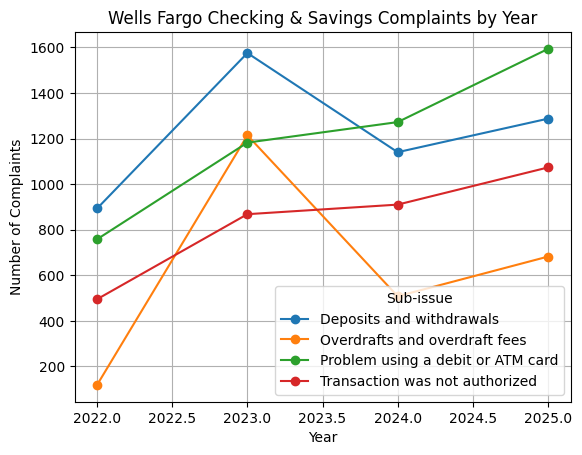

In [59]:
import matplotlib.pyplot as plt

trend_chart = trend_top.pivot(
    index="Year",
    columns="Sub-issue",
    values="Complaints"
)

trend_chart.plot(marker="o")

plt.title("Wells Fargo Checking & Savings Complaints by Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.legend(title="Sub-issue")
plt.grid(True)
plt.show()

In [60]:
from google.colab import files
uploaded = files.upload()

Saving complaints-2026-09-09_21_56.csv to complaints-2026-09-09_21_56 (7).csv


# 3. Geographic Analysis

This section identifies which states generated the highest raw number of checking and savings complaints.

These totals represent complaint volume, not complaint rates, because states differ in population and Wells Fargo customer base.


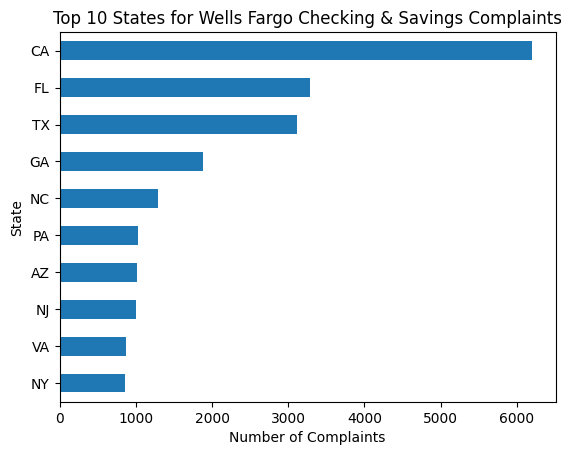

In [61]:
import matplotlib.pyplot as plt

state_counts.sort_values().plot(kind="barh")

plt.title("Top 10 States for Wells Fargo Checking & Savings Complaints")
plt.xlabel("Number of Complaints")
plt.ylabel("State")
plt.show()


# 4. Complaint Resolution Analysis

This section examines how Wells Fargo responded to complaints, including response timeliness and cases involving monetary or non-monetary relief.

In [62]:
checking["Company response to consumer"].value_counts()

,count
Company response to consumer,
Closed with explanation,24665
Closed with monetary relief,3428
Closed with non-monetary relief,1362


In [63]:
checking["Timely response?"].value_counts()

,count
Timely response?,
Yes,29453
No,2


In [64]:
checking["Timely response?"].value_counts(normalize=True) * 100

,proportion
Timely response?,
Yes,99.99321
No,0.00679


In [65]:
response_by_issue = pd.crosstab(
    checking["Sub-issue"],
    checking["Company response to consumer"]
)

response_by_issue.loc[
    [
        "Deposits and withdrawals",
        "Problem using a debit or ATM card",
        "Transaction was not authorized",
        "Overdrafts and overdraft fees"
    ]
]

Company response to consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief
Sub-issue,,,
Deposits and withdrawals,4179,499,217
Problem using a debit or ATM card,3882,753,170
Transaction was not authorized,2739,468,139
Overdrafts and overdraft fees,2137,357,29


# 5. Customer Narrative Analysis

This section examines customer-written complaint narratives to identify recurring themes within debit and ATM card complaints.

Keyword counts are exploratory and are not mutually exclusive, meaning one complaint may appear under multiple themes.

In [67]:
debit_narratives = checking[
    (checking["Sub-issue"] == "Problem using a debit or ATM card") &
    (checking["Consumer complaint narrative"].notna())
]

debit_narratives["Consumer complaint narrative"].head(10)

,Consumer complaint narrative
28,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX, Az XXXX ( ..."
31,I contacted Wells Fargo about fraudulent trans...
59,I found multiple unauthorized transactions on ...
74,XX/XX/XXXX I received an email that my account...
75,"On XXXX XXXX, {$700.00} was fraudulently taken..."
177,I previously filed a claim due to unauthorized...
193,I filed a dispute for an item I did not receiv...
212,XXXX $ was charged from atm two times I only h...
320,"On XX/XX/24, I received a call from the Wells ..."
335,Account always had hidden over draft fees bein...


In [68]:
themes = {
    "fraud": ["fraud", "fraudulent"],
    "unauthorized": ["unauthorized"],
    "dispute": ["dispute", "claim"],
    "ATM": ["atm"],
    "fee": ["fee", "fees"],
    "refund": ["refund", "reimburse", "reimbursed"]
}

results = {}

text = debit_narratives["Consumer complaint narrative"].str.lower()

for theme, words in themes.items():
    results[theme] = text.apply(
        lambda x: any(word in x for word in words)
    ).sum()

results

{'fraud': np.int64(1168),
 'unauthorized': np.int64(573),
 'dispute': np.int64(1591),
 'ATM': np.int64(503),
 'fee': np.int64(420),
 'refund': np.int64(450)}

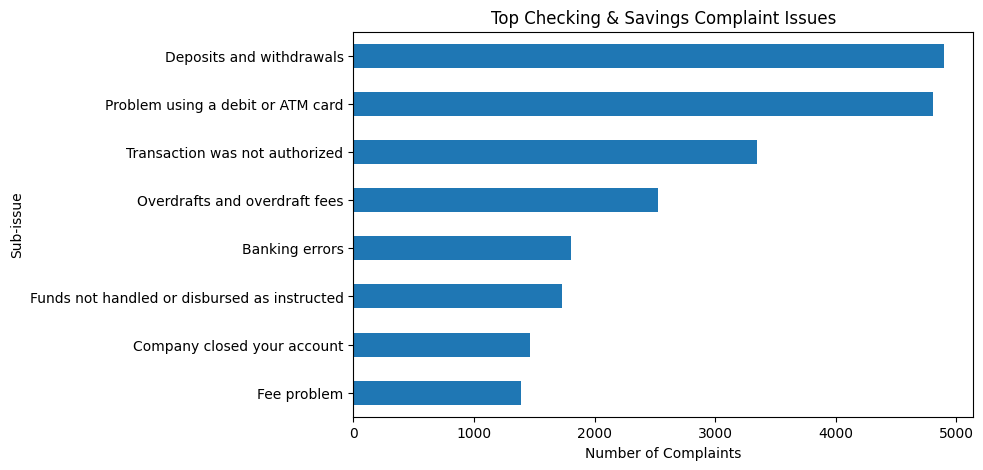

In [69]:
import matplotlib.pyplot as plt

top_issues = checking["Sub-issue"].value_counts().head(8)

plt.figure(figsize=(8,5))
top_issues.sort_values().plot(kind="barh")

plt.title("Top Checking & Savings Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Sub-issue")
plt.show()

In [70]:
checking["Date received"] = pd.to_datetime(checking["Date received"])
checking["Year"] = checking["Date received"].dt.year

trend = (
    checking.groupby(["Year", "Sub-issue"])
    .size()
    .reset_index(name="Complaints")
)

top_problems = [
    "Deposits and withdrawals",
    "Problem using a debit or ATM card",
    "Transaction was not authorized",
    "Overdrafts and overdraft fees"
]

trend_top = trend[trend["Sub-issue"].isin(top_problems)]

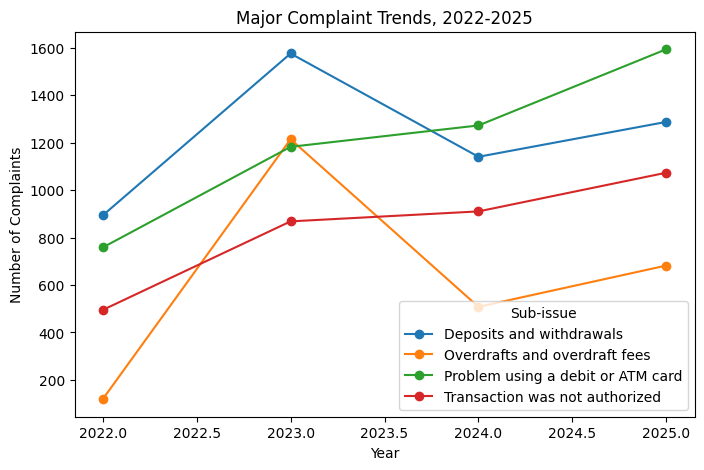

In [71]:
trend_chart = trend_top.pivot(
    index="Year",
    columns="Sub-issue",
    values="Complaints"
)

trend_chart.plot(marker="o", figsize=(8,5))

plt.title("Major Complaint Trends, 2022-2025")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.legend(title="Sub-issue")
plt.show()

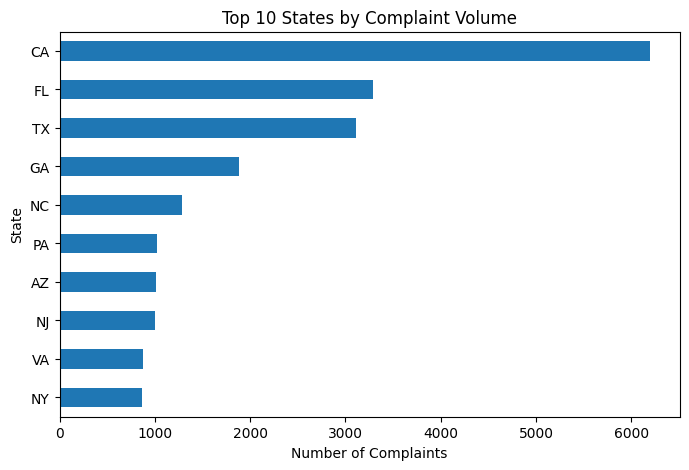

In [72]:
plt.figure(figsize=(8,5))
state_counts.sort_values().plot(kind="barh")

plt.title("Top 10 States by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("State")
plt.show()


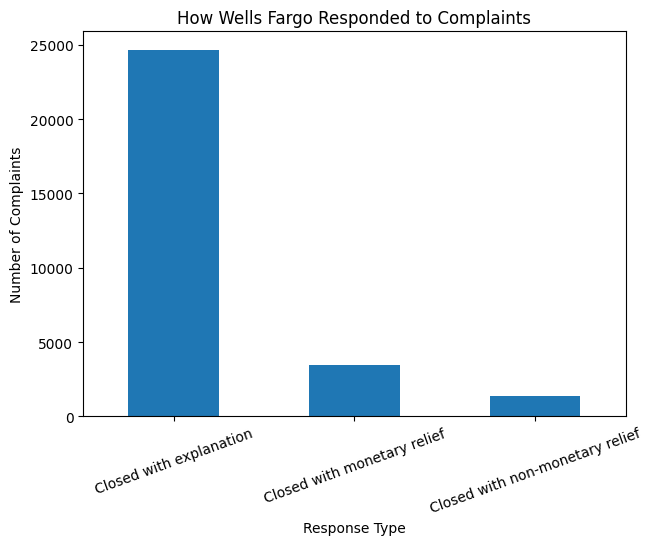

In [73]:
response_counts = checking["Company response to consumer"].value_counts()

plt.figure(figsize=(7,5))
response_counts.plot(kind="bar")

plt.title("How Wells Fargo Responded to Complaints")
plt.xlabel("Response Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=20)
plt.show()

In [74]:
total_complaints = len(checking)

debit_growth = (
    (1593 - 758) / 758
) * 100

timely_rate = (
    checking["Timely response?"]
    .value_counts(normalize=True)["Yes"] * 100
)

monetary_relief = (
    checking["Company response to consumer"]
    .value_counts()["Closed with monetary relief"]
)

print("Total Checking/Savings Complaints:", total_complaints)
print("Debit/ATM Complaint Growth:", round(debit_growth, 1), "%")
print("Timely Response Rate:", round(timely_rate, 2), "%")
print("Complaints With Monetary Relief:", monetary_relief)

Total Checking/Savings Complaints: 29455
Debit/ATM Complaint Growth: 110.2 %
Timely Response Rate: 99.99 %
Complaints With Monetary Relief: 3428


# 6. Key Findings and Business Recommendation

## Key Findings

### 1. Checking and savings accounts were the largest complaint category
29,455 checking and savings complaints were identified in the Wells Fargo dataset.

### 2. Debit and ATM card complaints increased sharply
Debit and ATM card complaints increased from 758 in 2022 to 1,593 in 2025, representing a 110.2% increase.

### 3. Unauthorized transaction complaints also increased
Unauthorized transaction complaints increased from 495 in 2022 to 1,073 in 2025, an increase of approximately 116.8%.

### 4. Response speed does not appear to be the main problem
Wells Fargo provided a timely response to approximately 99.99% of checking and savings complaints.

### 5. Debit and ATM card issues frequently resulted in monetary relief
Among the major complaint categories analyzed, debit and ATM card complaints produced the highest number of monetary-relief outcomes.

### 6. Fraud and dispute themes appeared frequently in customer narratives
The most common narrative themes included disputes and claims, fraud, unauthorized activity, ATM issues, fees, and refunds or reimbursement.

## Business Recommendation

The analysis suggests that Wells Fargo should focus on reducing debit-card and unauthorized transaction problems before they become complaints.

Potential areas for improvement include:

- stronger real-time fraud detection
- more proactive transaction alerts
- more detailed debit-card controls
- a simpler in-app dispute process
- clearer claim and reimbursement tracking

The next phase of this project will benchmark these recommendations against practices used by other financial institutions and simulate the potential impact of reducing complaint volume.